*7-21-2026, Subi Nair*

### Complete Water Balance Inputs for 2 Basins

* Loads precipitation, ET, and streamflow data for multiple HUC8 basins.
* `get_multiple_huc` returns one combined pandas dataframe for each HUC8 ID.
* Demonstrates two HUC8 IDs and stores their results as two separate data frames.
* Writes monthly and water-year CSV files in a separate output block, not inside the function.
* Creates a combined CSV that has both HUC8s in it


In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import glob
import os

In [2]:
# clone the git repository
!git clone https://github.com/watrs-csumb/huc8basin-water-balance

# set working directory to the cloned repo so all paths are relative
%cd /content/huc8basin-water-balance

Cloning into 'huc8basin-water-balance'...
remote: Enumerating objects: 956, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 956 (delta 15), reused 9 (delta 9), pack-reused 939 (from 1)
Receiving objects: 100% (956/956), 81.53 MiB | 17.64 MiB/s, done.
Resolving deltas: 100% (90/90), done.
/content/huc8basin-water-balance


### Set up constants
Includes the conversions for units that we will use later. Detailed description of the conversion process in the `Water Balance Calculations for Every HUC8` block.

In [3]:
# Unit conversions
cfs_to_af_factor = 1.9835
ft_to_mm = 304.8

### Function block
Functions by AJ Purdy

* `get_precip_data` accepts a HUC8 ID and a precipitation product.
* `get_et_data` accepts a HUC8 ID and an evapotranspiration model.
* `read_q_from_gaugeID` and `read_one_or_more_gauges` support streamflow processing.
* `get_q_data` returns monthly discharge data for one HUC8 basin.
* `get_multiple_huc` calls the three data functions and returns one combined DataFrame per HUC8 ID.

In [23]:
def get_precip_data(huc8id, product):
    '''
    input parameters:
    huc8id: USGS HUC8ID [string or INT]
    product: precipitation data product nickname (e.g., 'gridmet')

    output:
    out_df: dataframe of monthly precipitation timeseries for huc8id basin
    '''
    filename = glob.glob(f'data/p/{product}*/*{str(huc8id)}*.csv')[0]

    out_df = pd.read_csv(filename)
    out_df['date'] = pd.to_datetime(out_df['date'])
    out_df.rename(columns={'precipitation_mm': f'{product}_pr_mm'}, inplace=True)
    out_df.set_index('date', inplace=True)

    return out_df

def get_et_data(huc8id, model):
    '''
    input parameters:
    huc8id: USGS HUC8ID [string or INT]
    model: OpenET model name data product from data/et/

    output:
    out_df: dataframe of monthly evapotranspiration timeseries for huc8id basin
    '''
    filename = glob.glob(f'data/et/*{model}*.csv')[0]
    out_df = pd.read_csv(filename)
    out_df = out_df.loc[out_df.huc8==huc8id].copy()
    out_df['date']=pd.to_datetime(out_df['year_month'])
    out_df.set_index('date',inplace=True)
    out_df.rename(columns={'data_val': f'{model}_ET_mm'}, inplace=True)
    return out_df

def read_q_from_gaugeID(gaugeID):
    '''
    input parameters
    gaugeID: USGS streamflow gauge ID

    output:
    single_gauge: pandas dataframe aggregate monthly streamflow
    '''
    all_gauges = pd.read_csv('data/q/all_gauges_monthly_streamflow_summary.csv')
    single_gauge = all_gauges.loc[all_gauges.site_no==gaugeID].copy()
    single_gauge['date']=pd.to_datetime(single_gauge['year_month'])
    single_gauge.set_index('date',inplace=True)
    single_gauge['sum_daily_mean_cfs']
    return single_gauge

def read_one_or_more_gauges(gauges):
    """
    Reads one or more gauges and returns a monthly dataframe.
    Expects gauges to be either NaN, one gauge, or multiple gauges separated by commas.
    """

    if pd.isna(gauges):
        return None

    gauges = str(gauges)

    q_list = []

    for gauge in gauges.split(","):
        gauge = gauge.strip()

        # Handles values like "USGS-12345678"
        if "-" in gauge:
            gauge_id = gauge.split("-")[1]
        else:
            gauge_id = gauge

        q = read_q_from_gaugeID(int(gauge_id))
        q_list.append(q)

    if len(q_list) == 1:
        return q_list[0]

    # Combine multiple gauges by month
    q_all = pd.concat(q_list, ignore_index=True)

    q_sum = (
        q_all
        .groupby(["year_month", "water_year", "year", "month"], as_index=False)
        .agg({
            "mean_discharge_cfs": "sum",
            "sum_daily_mean_cfs": "mean",
            "n_days": "max",
            "n_missing_values": "min"
        })
    )

    q_sum["site_no"] = str(gauges)

    return q_sum[
        [
            "site_no",
            "year_month",
            "water_year",
            "year",
            "month",
            "mean_discharge_cfs",
            "sum_daily_mean_cfs",
            "n_days",
            "n_missing_values",
        ]
    ]

def get_q_data(huc8id):
    """
    input parameters:
    huc8id: USGS HUC8ID [string or int]

    output:
    q_df: dataframe of aggregate monthly discharge inflows and outflows for huc8id basin
    """

    meta = pd.read_csv("data/metadata/streamflow_gauges.csv")
    meta = meta.loc[meta.HUCID == huc8id]

    if meta.empty:
        raise ValueError(f"No metadata found for HUCID {huc8id}")

    gauges_in = meta["gauge_in"].iloc[0]
    gauges_out = meta["gauge_out"].iloc[0]



    q_in = read_one_or_more_gauges(gauges_in)
    q_out = read_one_or_more_gauges(gauges_out)

    # Case 1: both inflow and outflow gauges exist
    if q_in is not None and q_out is not None:
        q_df = q_out.merge(
            q_in,
            on=["year_month", "water_year", "year", "month"],
            how="outer",
            suffixes=("_out", "_in")
        )

        q_df["mean_discharge_cfs"] = (
            q_df["mean_discharge_cfs_out"].fillna(0)
            - q_df["mean_discharge_cfs_in"].fillna(0)
        )

        q_df["sum_daily_mean_cfs"] = (
            q_df["sum_daily_mean_cfs_out"].fillna(0)
            - q_df["sum_daily_mean_cfs_in"].fillna(0)
        )

        q_df["n_days"] = q_df[["n_days_out", "n_days_in"]].max(axis=1)

        q_df["n_missing_values"] = (
            q_df["n_missing_values_out"].fillna(0)
            + q_df["n_missing_values_in"].fillna(0)
        )

        q_df["site_no"] = huc8id

        q_df = q_df[
            [
                "site_no",
                "year_month",
                "water_year",
                "year",
                "month",
                "mean_discharge_cfs",
                "sum_daily_mean_cfs",
                "n_days",
                "n_missing_values",
            ]
        ]

    # Case 2: only outflow exists
    elif q_out is not None:
        q_df = q_out.copy()
        q_df["site_no"] = huc8id

    # Case 3: only inflow exists
    elif q_in is not None:
        q_df = q_in.copy()

        # Since this is only inflow, make it negative net discharge
        q_df["mean_discharge_cfs"] = -q_df["mean_discharge_cfs"]
        q_df["sum_daily_mean_cfs"] = -q_df["sum_daily_mean_cfs"]

        q_df["site_no"] = huc8id

    # Case 4: neither exists
    else:
        q_df = pd.DataFrame(
            columns=[
                "site_no",
                "year_month",
                "water_year",
                "year",
                "month",
                "mean_discharge_cfs",
                "sum_daily_mean_cfs",
                "n_days",
                "n_missing_values",
            ]
        )

    return q_df

### Function that combines precip, et, and streamflow functions

def get_multiple_huc(huc8_list, precip, et_model):
    """Return one combined DataFrame for each HUC8 ID.

    Parameters
    ----------
    huc8_list : list
        HUC8 IDs to process.
    precip : str
        Precipitation product passed to get_precip_data.
    et_model : str
        Evapotranspiration model passed to get_et_data.

    Returns
    -------
    dict
        Dictionary keyed by HUC8 ID. Each value is a combined DataFrame.
    """
    huc_dataframes = {}

    for huc8id in huc8_list:
        huc8id = int(huc8id)

        precip_df = get_precip_data(huc8id, precip)
        et_df = get_et_data(huc8id, et_model)
        q_df = get_q_data(huc8id)

        # Make sure streamflow uses the same datetime index as precip and ET.
        if not isinstance(q_df.index, pd.DatetimeIndex):
            q_df = q_df.copy()
            q_df["date"] = pd.to_datetime(q_df["year_month"])
            q_df.set_index("date", inplace=True)

        combined_df = pd.concat(
            [precip_df, et_df, q_df],
            axis=1,
            join="outer",
        ).sort_index()

        # Keep one copy when source tables contain columns with the same name.
        combined_df = combined_df.loc[:, ~combined_df.columns.duplicated()]
        combined_df.insert(0, "huc8_id", huc8id)

        huc_dataframes[huc8id] = combined_df

    return huc_dataframes


In [24]:
# check the metadata file
meta = pd.read_csv('data/metadata/streamflow_gauges.csv')
meta.iloc[1,:]


,1
HUCID,18090202
gauge_in,NaN
gauge_out,USGS-10251330


### Test two HUC8 IDs
Run the multiple hucs function using a HUC8 list (size 2 currently), precipitation product, and ET model. The function returns a dictionary containing one combined dataframe for each HUC8 ID.

In [25]:
# Inputs requested for get_multiple_huc
huc8_list = [18090202, 17060303]
precip = "gridmet"
et_model = "ensemble"

# Run all three data functions for both HUC8 IDs
# this is a combined dataframe
huc8_data = get_multiple_huc(huc8_list, precip, et_model)

# Split into two dataframes
huc_18090202_df = huc8_data[18090202]
huc_17060303_df = huc8_data[17060303]

# print("HUC8 18090202 shape:", huc_18090202_df.shape)
# display(huc_18090202_df.head())

# print("HUC8 17060303 shape:", huc_17060303_df.shape)
# display(huc_17060303_df.head())


### Water Balance Calculations for Every HUC8
This single block performs the complete calculation workflow for every HUC8 returned by `get_multiple_huc`:

* prepares the monthly output table
* removes months with missing streamflow values and missing ET values
* keeps only complete 12-month water years
* converts discharge to acre-feet and runoff depth in millimeters
* calculates monthly WBET and aggregates the results by water year
* plots precipitation, observed ET, and WBET for each HUC8

The completed monthly and water-year DataFrames are stored in `calculated_outputs` for the CSV block below.

---

### Conversions

This section first converts discharge (`sum_daily_mean_cfs`) into acre-feet:

1 cubic foot per second * 86,400 seconds in a day = 86,400 cubic feet per day

86,400 cubic feet / 43560 cubic feet per acre foot = 1.9835 acre-feet

So `sum_daily_mean_cfs` * 1.9835 acre-feet gives us the acre-feet total

Then, it converts the acre-feet into a depth in mm  

acre-feet / area in acres = depth in feet
There are 304.8 mm in a foot.

depth in feet * 304.8 = depth in mm

Then it creates a 'wbet' column that has the calculated water balance et values using precip and q

WBET = P - Q

`wy_summary` contains the water year aggregation table and is plotted at the end to compare WBET with observed ET


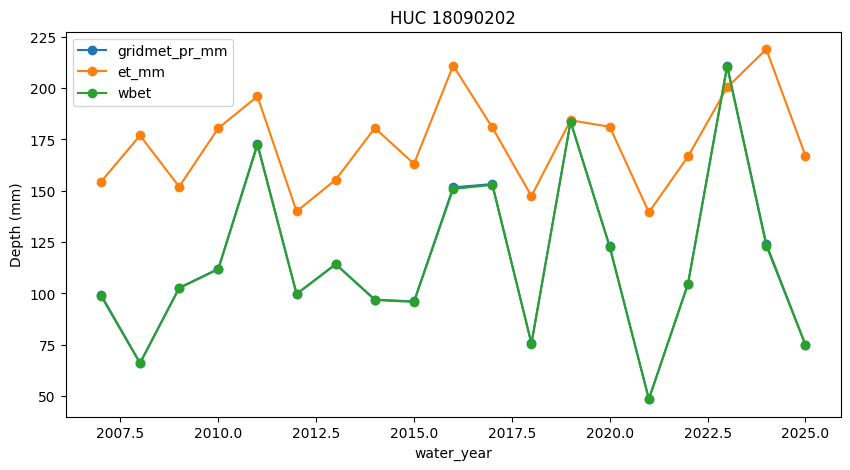

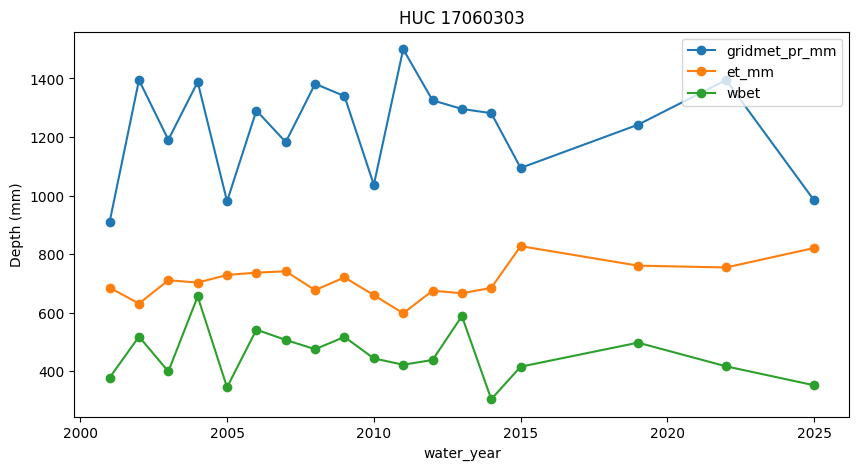

In [26]:
# Perform all filtering, conversions, WBET calculations, aggregation,
# and plotting here

# dictionary for each huc output
calculated_outputs = {}

for current_huc8id, combined_df in huc8_data.items():
    precip_column = f"{precip}_pr_mm"
    et_column = "et_mm"

    # Prepare the simple monthly output table
    monthly_output = combined_df.copy()
    monthly_output["huc8"] = current_huc8id
    monthly_output["units"] = "mm"

    monthly_output = monthly_output[
        [
            precip_column,
            "areaacres",
            "huc8",
            et_column,
            "units",
            "sum_daily_mean_cfs",
            "n_days",
            "n_missing_values",
            "water_year",
        ]
    ].copy()
    monthly_output.rename(columns={et_column: "et_mm"}, inplace=True)
    monthly_output.index.name = "date"

    # Use only months with complete streamflow data AND
    # any instances where the ET data is missing
    df_all = monthly_output[(monthly_output["n_missing_values"] == 0) & (monthly_output["et_mm"].notna())].copy()

    # Keep only complete 12-month water years
    wy_counts = df_all.groupby("water_year").size()
    complete_water_years = wy_counts[wy_counts == 12].index
    df_all = df_all[df_all["water_year"].isin(complete_water_years)].copy()

    # convert daily runoff means to acre feet
    df_all["acre_feet"] = df_all["sum_daily_mean_cfs"] * cfs_to_af_factor

    # acrefeet to water depth in mm
    df_all["depth_mm"] = (df_all["acre_feet"] / df_all["areaacres"]) * ft_to_mm

    # Calculate monthly Water Balance ET (Precipitation - Streamflow Depth (in mm))
    df_all["wbet"] = df_all[precip_column] - df_all["depth_mm"]

    # Aggregate all columns by water year
    wy_summary = df_all[
        ["water_year", precip_column, "et_mm", "depth_mm", "wbet"]
    ].groupby("water_year").sum()

    # Save the completed dfs for CSV output
    calculated_outputs[current_huc8id] = {
    "monthly": df_all,
    "water_year": wy_summary,
    }

    # Plot precipitation, observed ET, and calculated WBET for this HUC8
    ax = wy_summary[[precip_column, "et_mm", "wbet"]].plot(
        kind="line", marker="o", figsize=(10, 5)
    )
    ax.set_title(f"HUC {current_huc8id}")
    ax.set_ylabel("Depth (mm)")


### CSV Output

This block only writes the already-calculated dataframes to csvs. It also creates a combined csv that has both of the hucs in it.

* `HUC_<huc8id>_wbet_monthly.csv`
* `HUC_<huc8id>_wbet_water_year.csv`
* `combined_wbet_monthly.csv`
* `combined_wbet_water_year.csv`


In [27]:
# Write the completed outputs to CSV files
for current_huc8id, outputs in calculated_outputs.items():
    monthly_csv_path = f"HUC_{current_huc8id}_wbet_monthly.csv"
    water_year_csv_path = f"HUC_{current_huc8id}_wbet_water_year.csv"

    outputs["monthly"].to_csv(monthly_csv_path)
    outputs["water_year"].to_csv(water_year_csv_path)

    print(f"Saved monthly data to: {monthly_csv_path}")
    print(f"Saved water-year data to: {water_year_csv_path}")


## combined csv that has both of the hucs in one file for water year and one for monthly
pd.concat(
    [x["monthly"] for x in calculated_outputs.values()]
).to_csv("combined_wbet_monthly.csv")

pd.concat(
    {huc: x["water_year"] for huc, x in calculated_outputs.items()},
    names=["huc8"],
).to_csv("combined_wbet_water_year.csv")


Saved monthly data to: HUC_18090202_wbet_monthly.csv
Saved water-year data to: HUC_18090202_wbet_water_year.csv
Saved monthly data to: HUC_17060303_wbet_monthly.csv
Saved water-year data to: HUC_17060303_wbet_water_year.csv
